# K-Means Z500 Baseline — DJF Morocco

**Purpose:** Baseline method for direct comparison with `cmmvae_mswep_djf_winter_groups.ipynb`

**Method:** Plain K-Means clustering applied directly to Z500 fields.
No neural network. No precipitation knowledge during fitting.

**Scientific question:** Does the CMM-VAE's precipitation-supervised latent space
add skill compared to simple unsupervised Z500 clustering?

**Everything else is identical to the CMM-VAE notebook:**
- Same winter-group split (GroupShuffleSplit, 70/30, seed=42)
- Same GroupKFold 5-fold CV
- Same KMeans precipitation labels (training only)
- Same Q95 threshold (training only)
- Same BSS metrics (95th pct, cluster, tercile)
- Cell 17 prints a direct score comparison table

In [20]:
%load_ext autoreload
%autoreload 2

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.cluster import KMeans

import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy

import clustering_functions as cf
import skill_functions as sf
import preprocessing_functions as pf

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Parameters

> Kept **identical** to `cmmvae_mswep_djf_winter_groups.ipynb`  
> so that BSS scores are directly comparable.

In [21]:
import os, random
import numpy as np

g0                = 9.80665
djf_months        = [12, 1, 2]

cluster_number    = 4      # same k as CMM-VAE
pr_cluster_number = 4
filepath          = "results/baseline_kmeans_djf/"

HOLDOUT_FRAC  = 0.30
RANDOM_STATE  = 42        # same seed as CMM-VAE notebook
n_splits      = 5

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.makedirs(filepath, exist_ok=True)
print(f"Results will be saved to: {filepath}")

Results will be saved to: results/baseline_kmeans_djf/


### Data loading

**Load ERA5 Z500 (DJF, 1979-2020)**

In [22]:
z500 = pf.preprocess_dataset(
    filename              = '../data.nosync/era5_z500_daily_250_atlantic_1940_2022.nc',
    variable_name         = 'z',
    multiplication_factor = 1 / g0,
    geographical_filter   = 'new atlantic',
    months_filter         = djf_months,
    anomalies             = True,
    normalization         = False,
    rolling_window        = 5)

z500 = z500.where(z500['time.year'] > 1978, drop=True)
z500 = z500.where(z500['time.year'] < 2021, drop=True)

weights = np.cos(np.deg2rad(z500.latitude))
z500    = z500 * weights
z500    = z500 / z500.std()

print(f"Z500 DJF shape: {z500.shape}")

Z500 DJF shape: (3791, 25, 33)


**Load raw MSWEP precipitation (DJF, 1979-2020)**

In [23]:
pr_spatial = xr.open_dataset('../data.nosync/MSWEP_pr_total_DJF.nc')['precipitation']
pr_spatial = pr_spatial.where(pr_spatial['time.year'] < 2021, drop=True)

print(f"pr_spatial shape: {pr_spatial.shape}")
assert z500.shape[0] == pr_spatial.shape[0], (
    f"Time mismatch! Z500={z500.shape[0]}  MSWEP={pr_spatial.shape[0]}")
print("Time alignment OK.")

pr_spatial shape: (3791, 150, 160)
Time alignment OK.


### Winter-year group key

> **Same rule as CMM-VAE notebook:**  
> Dec year Y + Jan/Feb year Y+1 = winter Y  
> All 3 months always go to the same set.

In [24]:
times = pd.to_datetime(z500.time.values)

winter_year = np.array([t.year if t.month == 12 else t.year - 1
                        for t in times])

unique_winters = np.sort(np.unique(winter_year))
print(f"Total DJF days : {len(times)}")
print(f"Unique winters : {len(unique_winters)}")
print(f"Period         : winter {unique_winters[0]}/{unique_winters[0]+1} "
      f"to {unique_winters[-1]}/{unique_winters[-1]+1}")

Total DJF days : 3791
Unique winters : 43
Period         : winter 1978/1979 to 2020/2021


### Train / holdout split

> **Identical to CMM-VAE notebook** — same `GroupShuffleSplit`,  
> same `RANDOM_STATE=42`, same 70/30 ratio.  
> This guarantees a fair comparison: both models are trained and  
> evaluated on exactly the same winters.

In [25]:
X = cf.reshape_data_for_clustering(z500)   # (n_days, 825)

gss = GroupShuffleSplit(n_splits=1, test_size=HOLDOUT_FRAC, random_state=RANDOM_STATE)
train_idx, holdout_idx = next(gss.split(X, groups=winter_year))

train_winters   = sorted(set(winter_year[train_idx].tolist()))
holdout_winters = sorted(set(winter_year[holdout_idx].tolist()))

print(f"Training days : {len(train_idx)}   ({len(train_winters)} winters)")
print(f"Holdout  days : {len(holdout_idx)}   ({len(holdout_winters)} winters)")

overlap = set(train_winters) & set(holdout_winters)
print(f"Winter overlap: {len(overlap)}  {'<- LEAKAGE!' if overlap else '<- CLEAN'}")

Training days : 2619   (30 winters)
Holdout  days : 1172   (13 winters)
Winter overlap: 0  <- CLEAN


### Training and holdout winters — full list

In [26]:
print("=" * 65)
print(f"  TRAINING SET  ({len(train_winters)} winters)   [same as CMM-VAE]")
print("=" * 65)
for w in train_winters:
    n_days = int(np.sum(winter_year[train_idx] == w))
    print(f"  Winter {w}/{w+1-2000:02d}   Dec {w} + Jan/Feb {w+1}   ({n_days} days)")

print()
print("=" * 65)
print(f"  HOLDOUT SET  ({len(holdout_winters)} winters)   [same as CMM-VAE]")
print("=" * 65)
for w in holdout_winters:
    n_days = int(np.sum(winter_year[holdout_idx] == w))
    print(f"  Winter {w}/{w+1-2000:02d}   Dec {w} + Jan/Feb {w+1}   ({n_days} days)")

print()
print(f"Training: {len(train_idx)} days  ({100*len(train_idx)/(len(train_idx)+len(holdout_idx)):.1f} %)")
print(f"Holdout : {len(holdout_idx)} days  ({100*len(holdout_idx)/(len(train_idx)+len(holdout_idx)):.1f} %)")

  TRAINING SET  (30 winters)   [same as CMM-VAE]
  Winter 1978/-21   Dec 1978 + Jan/Feb 1979   (59 days)
  Winter 1979/-20   Dec 1979 + Jan/Feb 1980   (91 days)
  Winter 1980/-19   Dec 1980 + Jan/Feb 1981   (90 days)
  Winter 1983/-16   Dec 1983 + Jan/Feb 1984   (91 days)
  Winter 1985/-14   Dec 1985 + Jan/Feb 1986   (90 days)
  Winter 1987/-12   Dec 1987 + Jan/Feb 1988   (91 days)
  Winter 1988/-11   Dec 1988 + Jan/Feb 1989   (90 days)
  Winter 1989/-10   Dec 1989 + Jan/Feb 1990   (90 days)
  Winter 1991/-8   Dec 1991 + Jan/Feb 1992   (91 days)
  Winter 1992/-7   Dec 1992 + Jan/Feb 1993   (90 days)
  Winter 1993/-6   Dec 1993 + Jan/Feb 1994   (90 days)
  Winter 1994/-5   Dec 1994 + Jan/Feb 1995   (90 days)
  Winter 1995/-4   Dec 1995 + Jan/Feb 1996   (91 days)
  Winter 1996/-3   Dec 1996 + Jan/Feb 1997   (90 days)
  Winter 1997/-2   Dec 1997 + Jan/Feb 1998   (90 days)
  Winter 1998/-1   Dec 1998 + Jan/Feb 1999   (90 days)
  Winter 1999/00   Dec 1999 + Jan/Feb 2000   (91 days)
  Winter

### Precipitation labels — training winters only

> Same KMeans fitting as CMM-VAE notebook (training only, then transform holdout).

In [27]:
pr_values = pr_spatial.values            # (n_days, ny, nx)
nt, ny, nx = pr_values.shape
pr_flat = np.reshape(pr_values, [nt, ny * nx], order='F')

pr_flat_train   = pr_flat[train_idx]
pr_flat_holdout = pr_flat[holdout_idx]

kmeans_pr = KMeans(n_clusters=pr_cluster_number, n_init=10, random_state=RANDOM_STATE)
kmeans_pr.fit(pr_flat_train)

pr_labels_train   = kmeans_pr.predict(pr_flat_train)
pr_labels_holdout = kmeans_pr.predict(pr_flat_holdout)
pr_labels_all     = kmeans_pr.predict(pr_flat)

print("Precipitation KMeans fit on training winters only.")
print("Train label dist: " +
      "  ".join([f"c{k}={np.sum(pr_labels_train==k)}" for k in range(pr_cluster_number)]))

Precipitation KMeans fit on training winters only.
Train label dist: c0=1850  c1=493  c2=167  c3=109


### Q95 exceedance mask — training winters only

In [28]:
q95_threshold = np.percentile(pr_flat_train, 95, axis=0)

exceed_train   = (pr_flat_train   >= q95_threshold).astype(np.float32)
exceed_holdout = (pr_flat_holdout >= q95_threshold).astype(np.float32)
exceed_all     = (pr_flat         >= q95_threshold).astype(np.float32)

def flat_to_xarray(flat_exceed, time_coords, pr_ref):
    data_3d = np.reshape(flat_exceed, [len(time_coords), ny, nx], order='F')
    return xr.DataArray(
        data_3d,
        coords={'time': time_coords,
                'latitude':  pr_ref.latitude.values,
                'longitude': pr_ref.longitude.values},
        dims=['time', 'latitude', 'longitude'],
        name='precipitation')

threshold_qn95_train   = flat_to_xarray(exceed_train,   pr_spatial.time[train_idx],   pr_spatial)
threshold_qn95_holdout = flat_to_xarray(exceed_holdout, pr_spatial.time[holdout_idx], pr_spatial)
threshold_qn95_all     = flat_to_xarray(exceed_all,     pr_spatial.time,              pr_spatial)

print(f"Q95 from training only. Exceedance fraction: {exceed_train.mean():.3f} (expect ~0.05)")

Q95 from training only. Exceedance fraction: 0.051 (expect ~0.05)


### Baseline method: K-Means on Z500

> K-Means is fit **only on Z500 data** — no precipitation knowledge during fitting.  
> To produce probabilistic predictions compatible with BSS:  
> we convert distances to cluster centroids to probabilities  
> using a **softmax of negative distances**.

In [29]:
def distances_to_probs(distances):
    """
    Convert K-Means distances to cluster centroids into probabilities.
    Uses softmax of negative distances so that the nearest centroid
    gets the highest probability.

    Parameters
    ----------
    distances : np.ndarray, shape (n_days, k)
        Euclidean distances from each day to each centroid
        (output of KMeans.transform()).

    Returns
    -------
    probs : np.ndarray, shape (n_days, k)
        Row-wise probability vectors summing to 1.
    """
    neg_dist = -distances
    # Subtract row max for numerical stability before exp
    neg_dist -= neg_dist.max(axis=1, keepdims=True)
    exp_d = np.exp(neg_dist)
    return exp_d / exp_d.sum(axis=1, keepdims=True)

print("Helper function 'distances_to_probs' defined.")

Helper function 'distances_to_probs' defined.


### 5-Fold GroupKFold CV on training winters

> Same GroupKFold structure as CMM-VAE.  
> In each fold: K-Means fit on cv_train Z500, evaluated on cv_val Z500.  
> Best fold = highest BSS-95 on cv_val.  
> Out-of-fold predictions collected for reporting CV-BSS.

In [30]:
X_train_full   = X[train_idx]
X_holdout_arr  = X[holdout_idx]
winter_year_train = winter_year[train_idx]

gkf = GroupKFold(n_splits=n_splits)

best_bss_cv    = -np.inf
best_fold      = -1
best_centroids = None
fold_bss_list  = []

out_of_fold_preds = np.zeros((len(X_train_full), cluster_number), dtype=np.float32)

for fold, (cv_tr_idx, cv_val_idx) in enumerate(
        gkf.split(X_train_full, groups=winter_year_train)):

    print(f"\n--- FOLD {fold + 1}/{n_splits} ---")
    cv_tr_winters  = sorted(set(winter_year_train[cv_tr_idx].tolist()))
    cv_val_winters = sorted(set(winter_year_train[cv_val_idx].tolist()))
    print(f"  CV-train winters: {cv_tr_winters}")
    print(f"  CV-val   winters: {cv_val_winters}")

    X_cv_tr  = X_train_full[cv_tr_idx]
    X_cv_val = X_train_full[cv_val_idx]

    # Fit K-Means on THIS fold's training Z500 only
    km = KMeans(n_clusters=cluster_number, n_init=10, random_state=RANDOM_STATE)
    km.fit(X_cv_tr)

    # Predict on validation fold (probabilistic)
    dist_val  = km.transform(X_cv_val)          # (n_val, k) euclidean distances
    probs_val = distances_to_probs(dist_val)     # (n_val, k) probabilities

    out_of_fold_preds[cv_val_idx] = probs_val

    # BSS-95 on validation fold
    bss_cv_fold = sf.calculate_95pc_skill_score_probabilistic(
        cluster_number_z500        = cluster_number,
        z500_cluster_probabilities = probs_val,
        pr_spatial                 = pr_spatial.isel(time=train_idx[cv_val_idx]))

    print(f"  Fold {fold + 1}  BSS-95 (CV val) = {bss_cv_fold:.4f}")
    fold_bss_list.append(bss_cv_fold)

    if bss_cv_fold > best_bss_cv:
        best_bss_cv    = bss_cv_fold
        best_fold      = fold + 1
        best_centroids = km.cluster_centers_.copy()

print(f"\nBest fold: {best_fold}  |  CV BSS-95 = {best_bss_cv:.4f}")
print(f"All fold BSS-95: {[round(b,4) for b in fold_bss_list]}")


--- FOLD 1/5 ---
  CV-train winters: [1978, 1979, 1980, 1983, 1985, 1987, 1989, 1992, 1993, 1994, 1996, 1997, 1999, 2000, 2001, 2004, 2007, 2008, 2010, 2011, 2013, 2016, 2019, 2020]
  CV-val   winters: [1988, 1991, 1995, 1998, 2006, 2018]
Aggregating 3D precipitation data to 1D area-mean for 95pc skill score...
  Fold 1  BSS-95 (CV val) = 0.0688

--- FOLD 2/5 ---
  CV-train winters: [1978, 1979, 1985, 1987, 1988, 1991, 1992, 1993, 1994, 1995, 1997, 1998, 2000, 2001, 2004, 2006, 2007, 2010, 2011, 2013, 2016, 2018, 2019, 2020]
  CV-val   winters: [1980, 1983, 1989, 1996, 1999, 2008]
Aggregating 3D precipitation data to 1D area-mean for 95pc skill score...
  Fold 2  BSS-95 (CV val) = 0.0556

--- FOLD 3/5 ---
  CV-train winters: [1980, 1983, 1985, 1988, 1989, 1991, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2001, 2004, 2006, 2007, 2008, 2011, 2013, 2016, 2018, 2019, 2020]
  CV-val   winters: [1978, 1979, 1987, 1992, 2000, 2010]
Aggregating 3D precipitation data to 1D area-mean for 95pc ski

### Final K-Means fit — full training set

> Re-fit K-Means on **all** training winters (not just one fold).  
> This is the model used for holdout evaluation.

In [31]:
print(f"Fitting final K-Means (k={cluster_number}) on all {len(X_train_full)} training days ...")
kmeans_z500 = KMeans(n_clusters=cluster_number, n_init=20, random_state=RANDOM_STATE)
kmeans_z500.fit(X_train_full)

# Encode full dataset (all 1979-2020 days)
dist_full   = kmeans_z500.transform(X)             # (n_all, k)
probs_full  = distances_to_probs(dist_full)        # (n_all, k) <- probabilistic output

# Encode training and holdout separately
dist_train   = kmeans_z500.transform(X_train_full)
probs_train  = distances_to_probs(dist_train)

dist_holdout  = kmeans_z500.transform(X_holdout_arr)
probs_holdout = distances_to_probs(dist_holdout)

# Hard cluster labels (argmax)
final_labels = np.argmax(probs_full, axis=1).astype(float)
print("K-Means cluster distribution (full 1979-2020):")
for k in range(cluster_number):
    n = (final_labels == k).sum()
    print(f"  Cluster {k}: {n} days  ({100*n/len(final_labels):.1f} %)")

Fitting final K-Means (k=4) on all 2619 training days ...
K-Means cluster distribution (full 1979-2020):
  Cluster 0: 868 days  (22.9 %)
  Cluster 1: 1086 days  (28.6 %)
  Cluster 2: 983 days  (25.9 %)
  Cluster 3: 854 days  (22.5 %)


### Re-order clusters by precipitation (wettest = Regime 1)

> Same ordering logic as CMM-VAE notebook for visual comparability.

In [32]:
pr_total_daily = pr_spatial.sum(dim=['latitude', 'longitude']).values
assert len(pr_total_daily) == len(final_labels)

precip_sum = (pd.DataFrame({'values': pr_total_daily, 'label': final_labels.astype(int)})
              .groupby('label')['values'].sum().reset_index()
              .rename(columns={'label': 'index_old'})
              .sort_values('values', ascending=False).reset_index(drop=True))
precip_sum['index_new'] = np.arange(len(precip_sum))

labels_reordered = final_labels.copy()
for i in range(len(final_labels)):
    labels_reordered[i] = precip_sum.loc[
        precip_sum['index_old'] == int(final_labels[i]), 'index_new'].values[0]

# Re-order probability columns accordingly
col_order             = precip_sum['index_old'].values.tolist()
probs_full_reordered  = probs_full[:, col_order]
probs_train_reordered = probs_train[:, col_order]
probs_holdout_reord   = probs_holdout[:, col_order]
out_of_fold_reordered = out_of_fold_preds[:, col_order]

print(precip_sum)

   index_old      values  index_new
0          3  23415492.0          0
1          1  13436491.0          1
2          0  12744232.0          2
3          2   9839401.0          3


### Z500 Cluster Centres (precipitation-ordered)

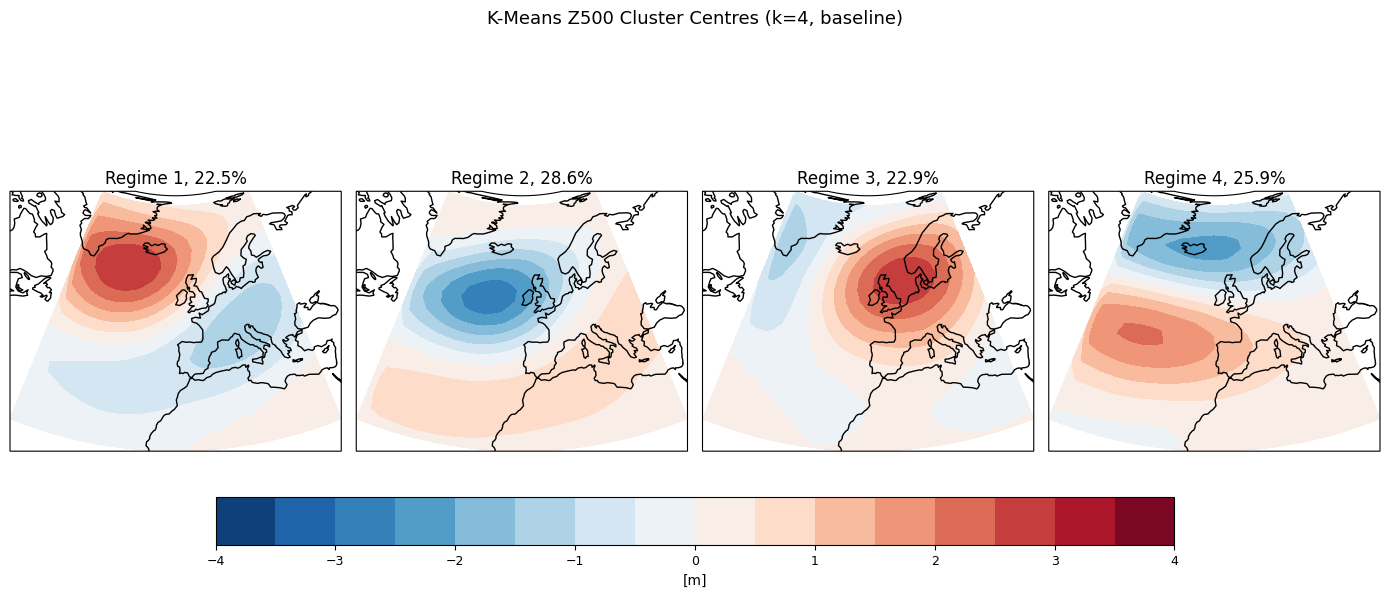

In [33]:
regime_names = [f'Regime {i+1}' for i in range(cluster_number)]

z500_lab = z500.assign_coords(label=('time', labels_reordered)) / weights
means    = z500_lab.groupby('label').mean()

cf.visualise_contourplot(
    cluster_centers = means,
    unit            = '[m]',
    regime_names    = regime_names,
    vmin=-4, vmax=4.5, steps=0.5,
    color_scheme    = 'RdBu_r',
    labels_data     = X,
    labels          = labels_reordered,
    borders         = False,
    col_number      = cluster_number,
    projection      = ccrs.AlbersEqualArea(central_longitude=-10, central_latitude=50))

plt.suptitle(f'K-Means Z500 Cluster Centres (k={cluster_number}, baseline)', fontsize=13)
plt.savefig(filepath + 'cluster_centers.png', dpi=150)
plt.show()

### Precipitation Odds Ratio — full period 1979-2020

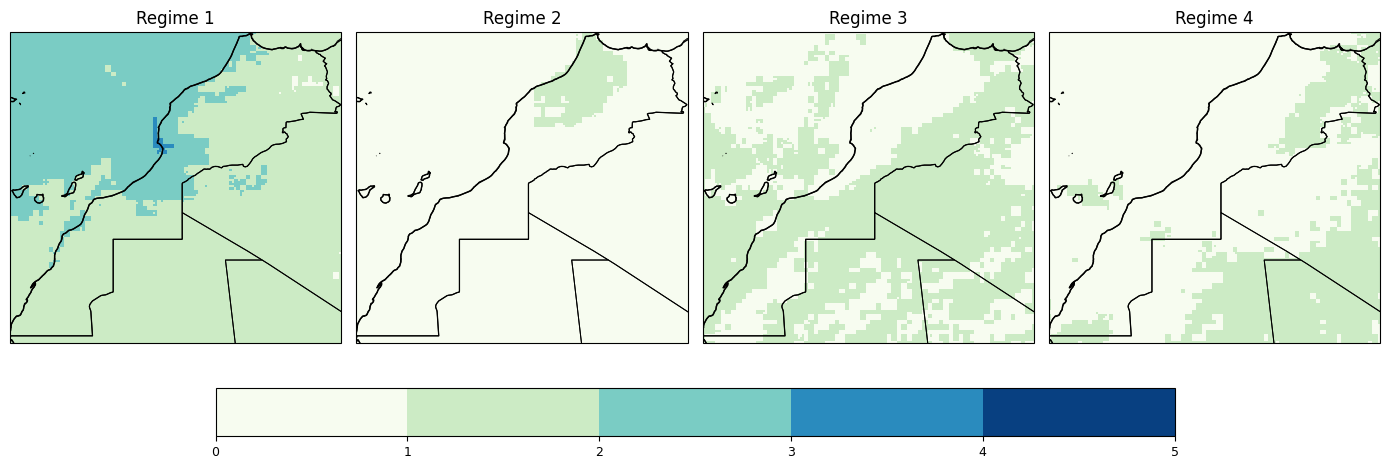

In [34]:
pr_qn95_ratio_full = cf.calculate_conditional_probability_change_label(
    threshold_matrix = threshold_qn95_all,
    labels           = labels_reordered,
    comparison       = 'ratio',
    shift_value      = 0)

cf.visualise_spatial_oddsratio(
    dataset_xarray = pr_qn95_ratio_full,
    unit           = '',
    color_scheme   = 'GnBu',
    vmin=0, vmax=5, steps=6,
    title          = 'K-Means Baseline: Odds ratio - 95th pct precipitation (full period)',
    regime_names   = regime_names,
    borders        = True,
    projection     = ccrs.PlateCarree(central_longitude=0),
    col_number     = cluster_number)

plt.savefig(filepath + 'precip_odds_ratio_full.png', dpi=150)
plt.show()

## Skill Scores

> **CV scores** use out-of-fold predictions on training winters.  
> **Holdout scores** use the unseen 30 % of winters.  
> Compare these directly with CMM-VAE skill_scores.csv.

In [35]:
print("=" * 55)
print("  K-MEANS BASELINE — BRIER SKILL SCORES")
print("=" * 55)

print("\n--- CV OUT-OF-FOLD (training winters) ---")
bss_95_cv = sf.calculate_95pc_skill_score_probabilistic(
    cluster_number_z500        = cluster_number,
    z500_cluster_probabilities = out_of_fold_reordered,
    pr_spatial                 = pr_spatial.isel(time=train_idx))
print(f"  BSS 95th percentile (CV):      {bss_95_cv:.4f}")

bss_cluster_cv = sf.calculate_cluster_skill_score_probabilistic(
    cluster_number_pr          = pr_cluster_number,
    cluster_number_z500        = cluster_number,
    pr_cluster_labels          = pr_labels_train,
    z500_cluster_probabilities = out_of_fold_reordered)
print(f"  BSS cluster         (CV):      {bss_cluster_cv:.4f}")

print("\n--- HOLDOUT SET (unseen winters) ---")
bss_95_holdout = sf.calculate_95pc_skill_score_probabilistic(
    cluster_number_z500        = cluster_number,
    z500_cluster_probabilities = probs_holdout_reord,
    pr_spatial                 = pr_spatial.isel(time=holdout_idx))
print(f"  BSS 95th percentile (holdout): {bss_95_holdout:.4f}")

bss_cluster_holdout = sf.calculate_cluster_skill_score_probabilistic(
    cluster_number_pr          = pr_cluster_number,
    cluster_number_z500        = cluster_number,
    pr_cluster_labels          = pr_labels_holdout,
    z500_cluster_probabilities = probs_holdout_reord)
print(f"  BSS cluster         (holdout): {bss_cluster_holdout:.4f}")

bss_tercile_holdout = sf.calculate_tercile_skill_score_probabilistic(
    cluster_number_z500        = cluster_number,
    z500_cluster_probabilities = probs_holdout_reord,
    pr_spatial                 = pr_spatial.isel(time=holdout_idx))
print(f"  BSS tercile (holdout, mean):   {float(bss_tercile_holdout.mean()):.4f}")

print()
print(f"  CV fold BSS-95 scores: {[round(b,4) for b in fold_bss_list]}")
print(f"  Best CV fold: {best_fold}")

pd.DataFrame({
    'method':               ['KMeans_Z500_baseline'],
    'k':                    [cluster_number],
    'bss_95_cv':            [bss_95_cv],
    'bss_cluster_cv':       [bss_cluster_cv],
    'bss_95_holdout':       [bss_95_holdout],
    'bss_cluster_holdout':  [bss_cluster_holdout],
    'bss_tercile_holdout':  [float(bss_tercile_holdout.mean())],
    'best_fold':            [best_fold],
    'best_cv_bss95':        [best_bss_cv],
    'train_winters':        [str(train_winters)],
    'holdout_winters':      [str(holdout_winters)]
}).to_csv(filepath + 'skill_scores_baseline.csv', index=False)
print("\nSaved to skill_scores_baseline.csv")

  K-MEANS BASELINE — BRIER SKILL SCORES

--- CV OUT-OF-FOLD (training winters) ---
Aggregating 3D precipitation data to 1D area-mean for 95pc skill score...
  BSS 95th percentile (CV):      0.0038
  BSS cluster         (CV):      0.0039

--- HOLDOUT SET (unseen winters) ---
Aggregating 3D precipitation data to 1D area-mean for 95pc skill score...
  BSS 95th percentile (holdout): 0.0279
  BSS cluster         (holdout): 0.0468
  BSS tercile (holdout, mean):   0.0240

  CV fold BSS-95 scores: [0.0688, 0.0556, 0.0497, 0.0653, 0.0476]
  Best CV fold: 1

Saved to skill_scores_baseline.csv


### Precipitation Odds Ratio — holdout winters only

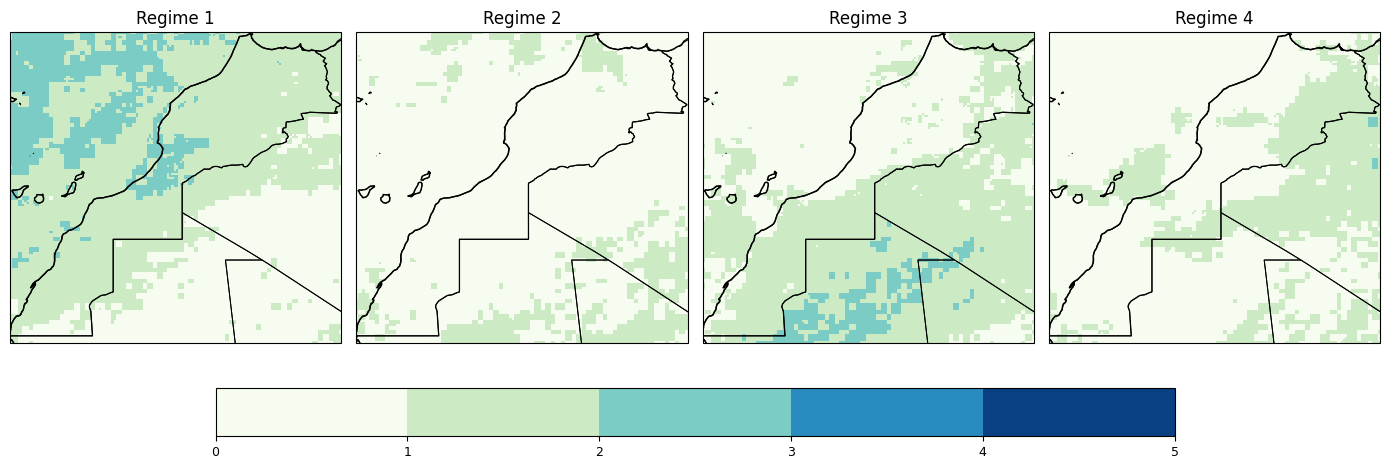

Holdout odds-ratio saved.


In [36]:
labels_holdout_raw      = np.argmax(probs_holdout, axis=1).astype(float)
labels_holdout_reordered = np.zeros_like(labels_holdout_raw)
for i in range(len(labels_holdout_raw)):
    labels_holdout_reordered[i] = precip_sum.loc[
        precip_sum['index_old'] == int(labels_holdout_raw[i]), 'index_new'].values[0]

pr_qn95_ratio_holdout = cf.calculate_conditional_probability_change_label(
    threshold_matrix = threshold_qn95_holdout,
    labels           = labels_holdout_reordered,
    comparison       = 'ratio',
    shift_value      = 0)

cf.visualise_spatial_oddsratio(
    dataset_xarray = pr_qn95_ratio_holdout,
    unit           = '',
    color_scheme   = 'GnBu',
    vmin=0, vmax=5, steps=6,
    title          = 'K-Means Baseline: Odds ratio - 95th pct precipitation (holdout winters)',
    regime_names   = regime_names,
    borders        = True,
    projection     = ccrs.PlateCarree(central_longitude=0),
    col_number     = cluster_number)

plt.savefig(filepath + 'precip_odds_ratio_holdout.png', dpi=150)
plt.show()
print("Holdout odds-ratio saved.")

### Side-by-side comparison: K-Means baseline vs CMM-VAE

> Load CMM-VAE scores (if available) and compare.

In [37]:
import os

baseline_path  = 'results/baseline_kmeans_djf/skill_scores_baseline.csv'
cmmvae_path    = 'results/cmmvae_mswep_djf_wgroups/skill_scores.csv'

df_base = pd.read_csv(baseline_path)

print("=" * 65)
print("  COMPARISON: K-Means Baseline vs CMM-VAE")
print("=" * 65)
print(f"  {'Metric':<30}  {'K-Means':<12}  {'CMM-VAE':<12}")
print("-" * 65)

metrics = [
    ('BSS 95th pct (CV)',      'bss_95_cv'),
    ('BSS cluster  (CV)',      'bss_cluster_cv'),
    ('BSS 95th pct (holdout)', 'bss_95_holdout'),
    ('BSS cluster  (holdout)', 'bss_cluster_holdout'),
    ('BSS tercile  (holdout)', 'bss_tercile_holdout'),
]

if os.path.exists(cmmvae_path):
    df_cmm = pd.read_csv(cmmvae_path)
    for label, col in metrics:
        bv = df_base[col].values[0] if col in df_base.columns else float('nan')
        cv = df_cmm[col].values[0]  if col in df_cmm.columns  else float('nan')
        winner = '  <-- CMM-VAE wins' if cv > bv else ('  <-- K-Means wins' if bv > cv else '')
        print(f"  {label:<30}  {bv:<12.4f}  {cv:<12.4f}{winner}")
else:
    print("  CMM-VAE results not yet available.")
    print("  Run cmmvae_mswep_djf_winter_groups.ipynb first, then re-run this cell.")
    for label, col in metrics:
        bv = df_base[col].values[0] if col in df_base.columns else float('nan')
        print(f"  {label:<30}  {bv:<12.4f}  {'N/A':<12}")

print("=" * 65)

  COMPARISON: K-Means Baseline vs CMM-VAE
  Metric                          K-Means       CMM-VAE     
-----------------------------------------------------------------
  BSS 95th pct (CV)               0.0038        0.0293        <-- CMM-VAE wins
  BSS cluster  (CV)               0.0039        0.0112        <-- CMM-VAE wins
  BSS 95th pct (holdout)          0.0279        0.0818        <-- CMM-VAE wins
  BSS cluster  (holdout)          0.0468        0.2766        <-- CMM-VAE wins
  BSS tercile  (holdout)          0.0240        0.0888        <-- CMM-VAE wins


---
## Holdout Accuracy

> How many holdout days did the K-Means baseline classify correctly?
> `probs_holdout_reord` = model's predicted cluster probabilities (reordered).  
> `pr_labels_holdout` = true KMeans precipitation-cluster labels.
---

---
## Holdout Accuracy

> For a fair comparison with CMM-VAE, we need to map each Z500 regime
> to a precipitation cluster prediction.

> **Method:** For each Z500 regime (0..K-1), find which precipitation
> cluster is most frequent among **training days** in that regime
> (majority-vote mapping — derived from training data only, no leakage).
> Apply that fixed map to holdout predictions, then compare to true labels.
---

In [38]:
# ── Step 1: build majority-vote map from TRAINING data only ─────────────
# Hard Z500 regime for each training day (reordered)
z500_train_hard = np.argmax(probs_train_reordered, axis=1)  # (n_train,)

# For each Z500 regime, find the most common precipitation cluster
majority_map = {}
for k in range(cluster_number):
    mask = (z500_train_hard == k)
    if mask.sum() == 0:
        majority_map[k] = 0
    else:
        majority_map[k] = int(np.bincount(pr_labels_train[mask]).argmax())

print('Majority-vote map (Z500 regime -> predicted precip cluster):')
for k, v in majority_map.items():
    n = (z500_train_hard == k).sum()
    print(f'  Z500 Regime {k+1} -> Precip Cluster {v+1}  ({n} training days)')

# ── Step 2: apply map to HOLDOUT predictions ──────────────────────────────
z500_holdout_hard = np.argmax(probs_holdout_reord, axis=1)  # (n_holdout,)
pred_labels = np.array([majority_map[k] for k in z500_holdout_hard])
true_labels = pr_labels_holdout

# ── Step 3: accuracy ──────────────────────────────────────────────────────
correct  = (pred_labels == true_labels).sum()
total    = len(true_labels)
accuracy = correct / total

most_common = np.bincount(true_labels).argmax()
clim_acc    = (true_labels == most_common).mean()

print()
print('=' * 50)
print('  HOLDOUT SET ACCURACY  (K-Means Baseline)')
print('=' * 50)
print(f'  Correct predictions : {correct} / {total}')
print(f'  Accuracy            : {accuracy*100:.1f} %')
print(f'  Climatology baseline: {clim_acc*100:.1f} %')
print(f'  Gain over baseline  : {(accuracy-clim_acc)*100:+.1f} pp')
print('=' * 50)

# Per-cluster breakdown
print('\nPer-cluster breakdown:')
print(f'  {"Cluster":<10} {"Correct":>8} {"Total":>8} {"Acc":>8}')
for k in range(pr_cluster_number):
    mask = (true_labels == k)
    c_k  = (pred_labels[mask] == k).sum()
    t_k  = mask.sum()
    a_k  = c_k / t_k if t_k > 0 else 0
    print(f'  Cluster {k+1:<4}  {c_k:>8} {t_k:>8} {a_k*100:>7.1f} %')


Majority-vote map (Z500 regime -> predicted precip cluster):
  Z500 Regime 1 -> Precip Cluster 1  (517 training days)
  Z500 Regime 2 -> Precip Cluster 1  (776 training days)
  Z500 Regime 3 -> Precip Cluster 1  (603 training days)
  Z500 Regime 4 -> Precip Cluster 1  (723 training days)

  HOLDOUT SET ACCURACY  (K-Means Baseline)
  Correct predictions : 781 / 1172
  Accuracy            : 66.6 %
  Climatology baseline: 66.6 %
  Gain over baseline  : +0.0 pp

Per-cluster breakdown:
  Cluster     Correct    Total      Acc
  Cluster 1          781      781   100.0 %
  Cluster 2            0      268     0.0 %
  Cluster 3            0       68     0.0 %
  Cluster 4            0       55     0.0 %
